In [ ]:
# Import Required Libraries
import numpy as np  # numeric operations
import pandas as pd  # data manipulation
# numpy and pandas are the primary libraries used for time-series processing


### Timedelta Object
Represents a duration — the difference between two dates or times. Use `Timedelta` when you want to represent time spans (days, hours, minutes, etc.).

In [ ]:
# Create Timestamp objects (examples)
# pandas.Timestamp accepts many human-readable formats
pd.Timestamp('2023-01-05 07:00')  # explicit datetime
pd.Timestamp('2023-01-05')         # date only
pd.Timestamp('2023')               # year only
pd.Timestamp('3rd June 2026 06:39AM')  # natural language format
pd.Timestamp('2026-03-06')


Timedelta('7669 days 11:14:50')

In [ ]:
# Standalone Timedelta creation (define durations explicitly)
# Timedelta can represent combined units: days, hours, minutes, seconds, ms, us
pd.Timedelta(days=2, hours=10, minutes=25, seconds=10, milliseconds=24, microseconds=28)


Timedelta('2 days 10:25:10.024028')

In [ ]:
# Arithmetic operations: add Timedelta to Timestamp to shift time
# Example: add 2 days 10 hours 25 minutes to a timestamp
pd.Timestamp('2026-11-17 00:00:00') + pd.Timedelta(days=2, hours=10, minutes=25)


Timestamp('2026-11-19 10:25:00')

In [64]:
pd.date_range(start='2005-11-17',end='2026-11-17', freq='D')+pd.Timedelta(days=2,hours=10,minutes=25)

DatetimeIndex(['2005-11-19 10:25:00', '2005-11-20 10:25:00',
               '2005-11-21 10:25:00', '2005-11-22 10:25:00',
               '2005-11-23 10:25:00', '2005-11-24 10:25:00',
               '2005-11-25 10:25:00', '2005-11-26 10:25:00',
               '2005-11-27 10:25:00', '2005-11-28 10:25:00',
               ...
               '2026-11-10 10:25:00', '2026-11-11 10:25:00',
               '2026-11-12 10:25:00', '2026-11-13 10:25:00',
               '2026-11-14 10:25:00', '2026-11-15 10:25:00',
               '2026-11-16 10:25:00', '2026-11-17 10:25:00',
               '2026-11-18 10:25:00', '2026-11-19 10:25:00'],
              dtype='datetime64[ns]', length=7671, freq='D')

In [ ]:
# Real-life example: deliveries dataset
# Make sure 'Datasets/deliveries.csv' exists in the project Datasets folder
# We'll inspect a few rows to understand the date columns
df = pd.read_csv('Datasets/deliveries.csv')
df.head()


<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\1894802995.py:2: SyntaxWarning: invalid escape sequence '\d'
  df=pd.read_csv('Datasets\deliveries.csv')


,order_date,delivery_date
0,5/24/98,2/5/99
1,4/22/92,3/6/98
2,2/10/91,8/26/92
3,7/21/92,11/20/97
4,9/2/93,6/10/98


In [ ]:
# Convert delivery/order columns to datetime before computing differences
# errors='coerce' converts invalid parsing to NaT
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')


C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\3165684011.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['delivery_date']=pd.to_datetime(df['delivery_date'])
C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\3165684011.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['order_date']=pd.to_datetime(df['order_date'])


In [ ]:
# Compute delivery time period as a Timedelta column
# This subtracts two datetimes and stores a Timedelta for each row
df['delivery_time_period'] = df['delivery_date'] - df['order_date']


In [ ]:
# Mean of Timedelta column: returns a Timedelta (average delivery time)
df['delivery_time_period'].mean()


Timedelta('1217 days 22:53:53.532934128')

### Time Series
A time series is a dataset that records observations over time. Time-series data allow us to analyze trends, seasonality, and other temporal patterns to understand how variables change and what factors may influence them.


Example
- Financial Data (company stocks)
- Natural Data (rainfall measurement)
- Event Data (COVID-19 cases over time)
- Medical Data (heart-rate monitoring)

Types of operations on time series:
- Time series analysis (trend, seasonality, decomposition)
- Time series forecasting


In [69]:
# Load Datasets
google=pd.read_csv('Datasets/google.csv')

google.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
4466,2022-05-16,2307.679932,2332.149902,2286.699951,2295.850098,2295.850098,1164100
4467,2022-05-17,2344.550049,2344.550049,2306.750000,2334.030029,2334.030029,1078800
4468,2022-05-18,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100
4469,2022-05-19,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600
4470,2022-05-20,2241.709961,2251.000000,2127.459961,2186.260010,2186.260010,1878100


In [70]:
google.size

31297

In [79]:
google.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4471 entries, 0 to 4470
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       4471 non-null   datetime64[ns]
 1   Open       4471 non-null   float64       
 2   High       4471 non-null   float64       
 3   Low        4471 non-null   float64       
 4   Close      4471 non-null   float64       
 5   Adj Close  4471 non-null   float64       
 6   Volume     4471 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 244.6 KB


In [87]:
google['Date']=pd.to_datetime(google['Date'],errors='coerce')

In [99]:
google.set_index('Date',inplace=True)

In [118]:
google.loc['2021-12-31']

Open           2910.879883
High           2927.300049
Low            2893.550049
Close          2893.590088
Adj Close      2893.590088
Volume       864900.000000
Name: 2021-12-31 00:00:00, dtype: float64

In [122]:
# Partical Indexing -> select a perticular year/month
google.loc['2021']

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2021-01-04,1757.540039,1760.650024,1707.849976,1728.239990,1728.239990,1901900
2021-01-05,1725.000000,1747.670044,1718.015015,1740.920044,1740.920044,1145300
2021-01-06,1702.630005,1748.000000,1699.000000,1735.290039,1735.290039,2602100
2021-01-07,1740.060059,1788.400024,1737.050049,1787.250000,1787.250000,2265000
2021-01-08,1787.979980,1809.839966,1773.535034,1807.209961,1807.209961,2050600
...,...,...,...,...,...,...
2021-12-27,2949.270020,2968.530029,2945.000000,2961.280029,2961.280029,662800
2021-12-28,2967.489990,2967.489990,2918.709961,2928.959961,2928.959961,931200
2021-12-29,2928.590088,2943.675049,2910.090088,2930.090088,2930.090088,851100


In [135]:
# Create year month and day-name
google['month_name']=google.index.month_name()
google['day_name']=google.index.day_name()
google['quarter']=google.index.quarter

In [136]:
google.head()

,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,
2004-08-19,49.813290,51.835709,47.800831,49.982655,49.982655,44871361,August,Thursday,3
2004-08-20,50.316402,54.336334,50.062355,53.952770,53.952770,22942874,August,Friday,3
2004-08-23,55.168217,56.528118,54.321388,54.495735,54.495735,18342897,August,Monday,3
2004-08-24,55.412300,55.591629,51.591621,52.239197,52.239197,15319808,August,Tuesday,3
2004-08-25,52.284027,53.798351,51.746044,52.802086,52.802086,9232276,August,Wednesday,3


- slicing

In [141]:
google.loc['2021-10-15':'2021-10-25']

,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,
2021-10-15,2844.000000,2844.000000,2821.290039,2833.500000,2833.500000,1062500,October,Friday,4
2021-10-18,2824.270020,2859.975098,2824.270020,2859.209961,2859.209961,828200,October,Monday,4
2021-10-19,2865.830078,2882.139893,2861.919922,2876.439941,2876.439941,765800,October,Tuesday,4
2021-10-20,2884.449951,2884.955078,2838.239990,2848.300049,2848.300049,897000,October,Wednesday,4
2021-10-21,2843.840088,2856.989990,2832.739990,2855.610107,2855.610107,742500,October,Thursday,4
2021-10-22,2807.020020,2831.169922,2743.409912,2772.500000,2772.500000,1509100,October,Friday,4
2021-10-25,2776.209961,2784.115967,2734.969971,2775.459961,2775.459961,1054100,October,Monday,4


In [147]:
# fetch info a perticular data every year -> limitation of timedelta
google.head()
pd.date_range(start='2005-01-06',end='2022-01-06',freq=pd.DateOffset(years=1))
google[google.index.isin(pd.date_range(start='2005-01-06',end='2022-01-06',freq=pd.DateOffset(years=1)))]

,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,
2005-01-06,97.175758,97.584229,93.509506,93.922951,93.922951,20852067,January,Thursday,1
2006-01-06,227.581970,234.371521,225.773743,231.960556,231.960556,35646914,January,Friday,1
2009-01-06,165.868286,169.763687,162.585587,166.406265,166.406265,12898566,January,Tuesday,1
2010-01-06,311.761444,311.761444,302.047852,302.994293,302.994293,7987226,January,Wednesday,1
2011-01-06,304.199799,308.060303,303.885956,305.604523,305.604523,4131026,January,Thursday,1
2012-01-06,328.344299,328.767700,323.681763,323.796326,323.796326,5405987,January,Friday,1
2014-01-06,554.426880,557.340942,551.154114,556.573853,556.573853,3551864,January,Monday,1
2015-01-06,513.589966,514.761719,499.678131,500.585632,500.585632,2899940,January,Tuesday,1
2016-01-06,730.000000,747.179993,728.919983,743.619995,743.619995,1947000,January,Wednesday,1


<Axes: xlabel='Date'>

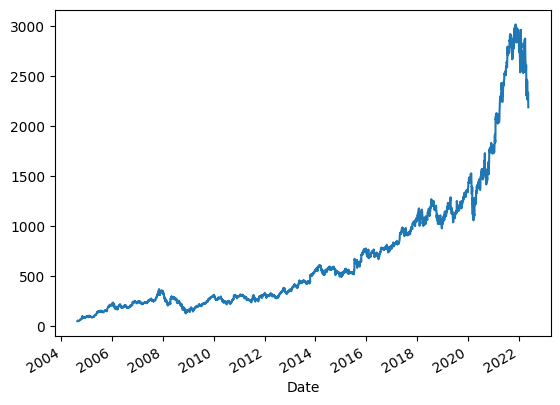

In [148]:
# viz a single col
google['Close'].plot()

<Axes: xlabel='Date'>

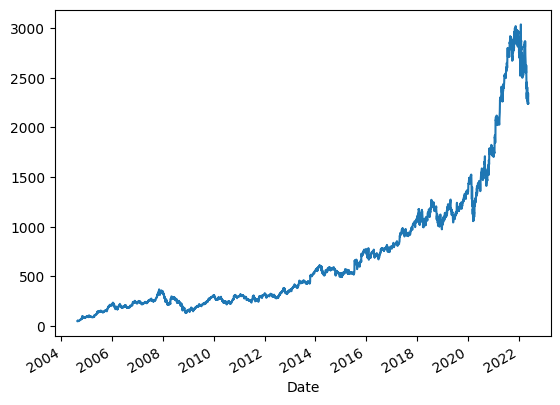

In [149]:
# plot multiple col together
google

<Axes: xlabel='Date'>

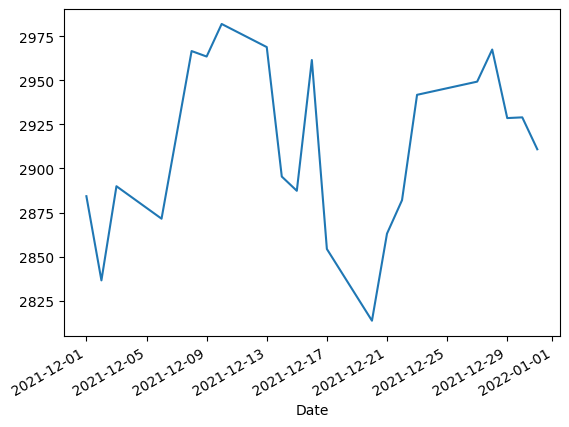

In [158]:
# Plot Graph a perticular year/month/day

google.loc['2021-12']['Open'].plot()

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\2698761387.py:2: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  google['Close'].asfreq('Q').plot()


<Axes: xlabel='Date'>

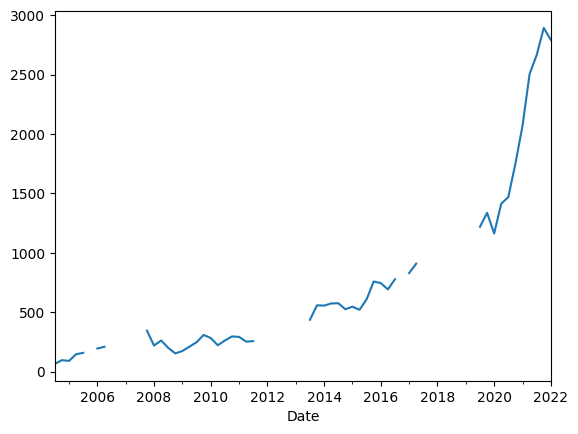

In [180]:
# quaterly trend
google['Close'].asfreq('Q').plot()


<Axes: ylabel='Close'>

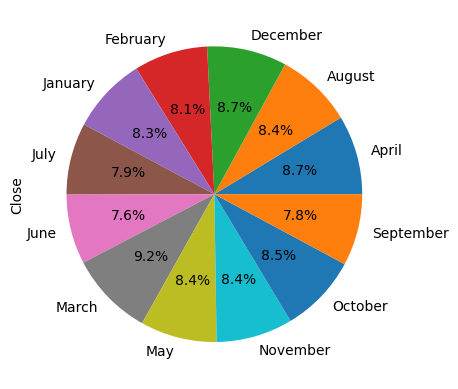

In [191]:
# monthly analysis
google.groupby('month_name')['Close'].sum().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='Close'>

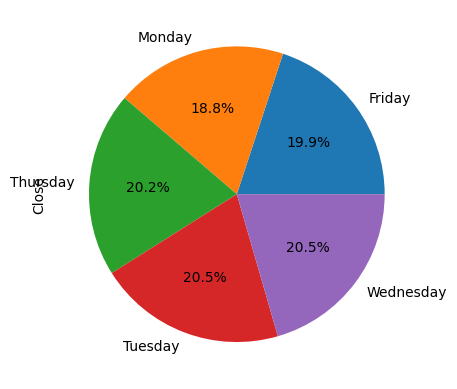

In [192]:
# Day Analysis
google.groupby('day_name')['Close'].sum().plot(kind='pie',autopct="%0.1f%%")

<Axes: ylabel='Close'>

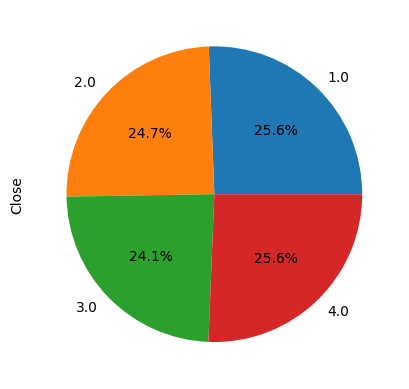

In [ ]:
# quarterly trend
google.groupby('quarter')['Close'].sum().plot(kind='pie', autopct="%0.1f%%")


- Frequency

In [174]:
# Frequency
google.asfreq('12H',method='bfill')


C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\3806313110.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google.asfreq('12H',method='bfill')


,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,
2004-08-19 00:00:00,49.813290,51.835709,47.800831,49.982655,49.982655,44871361.0,August,Thursday,3.0
2004-08-19 12:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-20 00:00:00,50.316402,54.336334,50.062355,53.952770,53.952770,22942874.0,August,Friday,3.0
2004-08-20 12:00:00,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
2004-08-21 00:00:00,55.168217,56.528118,54.321388,54.495735,54.495735,18342897.0,August,Monday,3.0
...,...,...,...,...,...,...,...,...,...
2022-05-18 00:00:00,2304.750000,2313.913086,2242.840088,2248.020020,2248.020020,1399100.0,May,Wednesday,2.0
2022-05-18 12:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0
2022-05-19 00:00:00,2236.820068,2271.750000,2209.360107,2214.909912,2214.909912,1459600.0,May,Thursday,2.0


<h3>Resampling</h3>

Resampling involves changing the frequency of your time series observations.<br>

Two types of resampling:<br>

<b>Upsampling:</b> Where you increase the frequency of the samples, such as from minutes to seconds.<br>
<b>Downsampling:</b> Where you decrease the frequency of the samples, such as from seconds to minutes or minutes to hours.

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\2268602852.py:2: FutureWarning: 'y' is deprecated and will be removed in a future version, please use 'YE' instead.
  google['Close'].resample('y').mean().plot()
C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\2268602852.py:3: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  google['Close'].plot()
C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\2268602852.py:3: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  google['Close'].plot()


<Axes: xlabel='Date'>

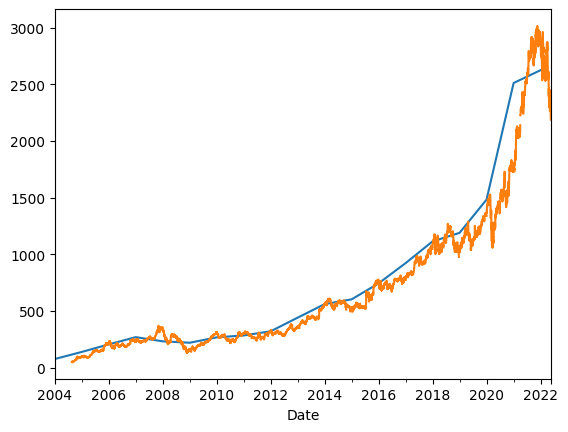

In [220]:
# Downsampling
google['Close'].resample('y').mean().plot()
google['Close'].plot()

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\2226105503.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  google['Close'].resample('12H').interpolate(method='spline',order=2).plot()


<Axes: xlabel='Date'>

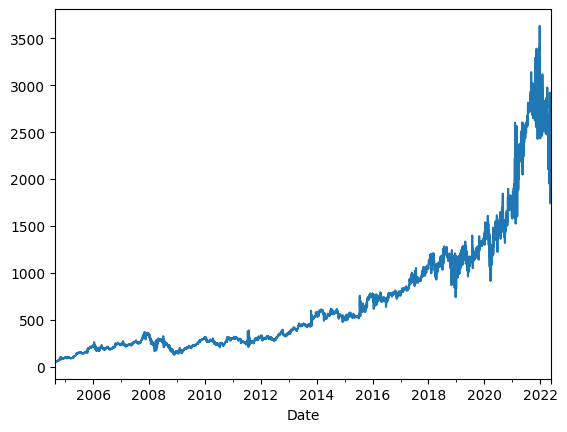

In [232]:
# Upsampling
google['Close'].resample('12H').interpolate(method='spline',order=2).plot()

In [228]:
google.asfreq('MS',method='ffill')

,Open,High,Low,Close,Adj Close,Volume,month_name,day_name,quarter
Date,,,,,,,,,
2004-09-01,51.158245,51.292744,49.648903,49.937820,49.937820,9181687.0,September,Wednesday,3.0
2004-10-01,65.155777,66.869354,64.209328,66.042458,66.042458,15196748.0,October,Friday,4.0
2004-11-01,96.413620,98.465927,95.277878,97.648987,97.648987,24541444.0,November,Monday,4.0
2004-12-01,90.635277,90.909248,89.439758,89.643990,89.643990,15787153.0,December,Wednesday,4.0
2005-01-01,99.243011,99.566795,95.920464,96.035034,96.035034,15394487.0,December,Friday,4.0
...,...,...,...,...,...,...,...,...,...
2022-01-01,2910.879883,2927.300049,2893.550049,2893.590088,2893.590088,864900.0,December,Friday,4.0
2022-02-01,2756.699951,2764.000000,2691.364990,2757.570068,2757.570068,2560200.0,February,Tuesday,1.0
2022-03-01,2689.600098,2722.219971,2667.570068,2683.360107,2683.360107,1232000.0,March,Tuesday,1.0


### Rolling Window(Smoothing)
Time series data in original can be quite volatile, especially on smaller aggregation lavel

<Axes: xlabel='Date'>

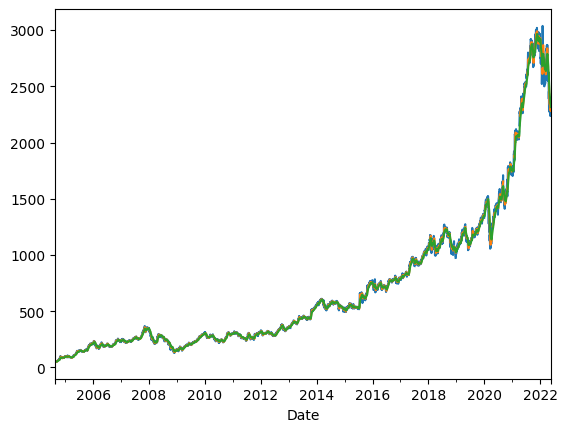

In [247]:
# Rolling window
google['Open'].plot()
google['Open'].rolling(7).mean().plot()
google['Open'].ewm(7).mean().plot()

### Shifting()
The shift() function is Pandas is used to , well shift the entries Series up or down by the desire number of periods

In [251]:
# shift
google['High'].shift(-1)

Date
2004-08-19      54.336334
2004-08-20      56.528118
2004-08-23      55.591629
2004-08-24      53.798351
2004-08-25      53.773445
                 ...     
2022-05-16    2344.550049
2022-05-17    2313.913086
2022-05-18    2271.750000
2022-05-19    2251.000000
2022-05-20            NaN
Freq: B, Name: High, Length: 4632, dtype: float64

In [261]:
 # Shift Example
login=pd.read_csv('Datasets/login.csv',header=None)
login=login[[1,2]]
login.head()
login.rename(columns={1:"user_id",2:'login-time'},inplace=True)
login.head()

,user_id,login-time
0,466,2017-01-07 18:24:07
1,466,2017-01-07 18:24:55
2,458,2017-01-07 18:25:18
3,458,2017-01-07 18:26:21
4,592,2017-01-07 19:09:59


In [266]:
user_df=login[login['user_id']==413]
user_df.head()

,user_id,login-time
11,413,2017-01-09 12:29:25
12,413,2017-01-09 12:40:39
14,413,2017-01-09 14:08:04
33,413,2017-01-10 14:36:23
35,413,2017-01-10 15:22:45


In [270]:
# Calculate everage retuening time
user_df['login-time']=pd.to_datetime(user_df['login-time'])
user_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 222 entries, 11 to 2997
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     222 non-null    int64         
 1   login-time  222 non-null    datetime64[ns]
dtypes: datetime64[ns](1), int64(1)
memory usage: 5.2 KB


C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\477629509.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['login-time']=pd.to_datetime(user_df['login-time'])


In [ ]:
user_df['shifted']=user_df['login-time'].shift(1)

C:\Users\Neelesh Ranpuriya\AppData\Local\Temp\ipykernel_9236\4184364657.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_df['shifted']=user_df['login-time'].shift(1)


In [274]:
(user_df['login-time']-user_df['shifted']).mean()

Timedelta('1 days 15:05:13.384615384')